# Pytorch Custom Datasets

## 0. Importing pytorch and setting up device-agnostic code

In [199]:
import torch 
from torch import nn
torch.__version__

'2.2.2'

In [200]:
import numpy as np
print(np.__version__)
print(np.__file__)


1.26.4
c:\Users\reza\miniconda3\envs\envMain\lib\site-packages\numpy\__init__.py


In [201]:
import sys
print(sys.executable)
print(sys.prefix)
print(sys.base_prefix)



c:\Users\reza\miniconda3\envs\envMain\python.exe
c:\Users\reza\miniconda3\envs\envMain
c:\Users\reza\miniconda3\envs\envMain


In [202]:
# Setup device-agnostic code
device = 'cuda' if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Get data

In [203]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"
# 
# # If the image folder doesn't exist, download it and prepare it ...
# if image_path.is_dir():
#     print(f"{image_path} directory already exists... skipping download")
# else:
#     print(f"{image_path} does not exist, creating one...")
#     image_path.mkdir(parents=True, exist_ok=True)
# # Download pizza, steak and sushi data
# with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
#     request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
#     print("Downloaded pizza, steak, sushi data...")
#     f.write(request.content)
# 
# # Unzip pizza, steak, sushi data
# with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
#     print("Unzipping pizza, steak and sushi data...")
#     zip_ref.extractall(image_path)

## 2. Data preparation & exploration

In [204]:
import os
def walk_through_dir(dir_path):
    """Walks through dir_path returning it's contents."""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

In [205]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'


In [206]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing an image

In [207]:
image_path

WindowsPath('data/pizza_steak_sushi')

The image path is: data\pizza_steak_sushi\train\sushi\148799.jpg
Image class: sushi
Image height: 512
Image width 384


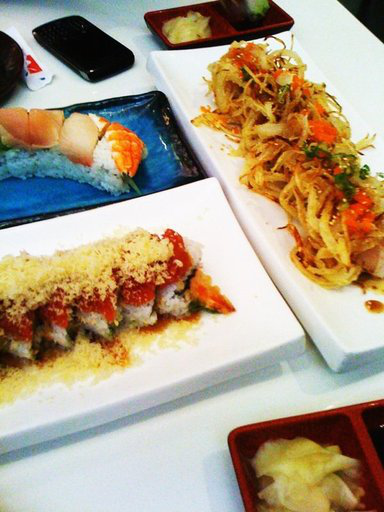

In [208]:
import random
from PIL import Image

# Set a seed
# random.seed(42)

# 1. Get all image path
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Pick a radom image
random_image_path = random.choice(image_path_list)

# 3. Get image class
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Display some meta data
print(f"The image path is: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width {img.width}")
img

In [209]:
import matplotlib
print(matplotlib.__version__)
print(matplotlib.rcParams)


3.10.7
_internal.classic_mode: False
agg.path.chunksize: 0
animation.bitrate: -1
animation.codec: h264
animation.convert_args: ['-layers', 'OptimizePlus']
animation.convert_path: convert
animation.embed_limit: 20.0
animation.ffmpeg_args: []
animation.ffmpeg_path: ffmpeg
animation.frame_format: png
animation.html: none
animation.writer: ffmpeg
axes.autolimit_mode: data
axes.axisbelow: line
axes.edgecolor: white
axes.facecolor: black
axes.formatter.limits: [-5, 6]
axes.formatter.min_exponent: 0
axes.formatter.offset_threshold: 4
axes.formatter.use_locale: False
axes.formatter.use_mathtext: False
axes.formatter.useoffset: True
axes.grid: False
axes.grid.axis: both
axes.grid.which: major
axes.labelcolor: white
axes.labelpad: 4.0
axes.labelsize: medium
axes.labelweight: normal
axes.linewidth: 0.8
axes.prop_cycle: cycler('color', ['#8dd3c7', '#feffb3', '#bfbbd9', '#fa8174', '#81b1d2', '#fdb462', '#b3de69', '#bc82bd', '#ccebc4', '#ffed6f'])
axes.spines.bottom: True
axes.spines.left: True
axes

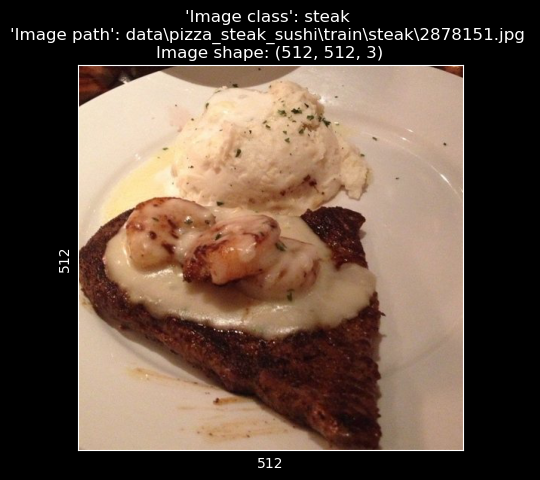

In [210]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get all image path
all_image_paths = list(image_path.glob("*/*/*.jpg"))

# 2 .Pick a random image path
random_image_path = random.choice(all_image_paths)

# 3. Get image class
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)
image_as_array = np.asarray(img)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5))
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_xlabel(img.width)
ax.set_ylabel(img.height)
ax.set_title(f"'Image class': {image_class} \n'Image path': {random_image_path} \nImage shape: {image_as_array.shape}")
ax.imshow(img)
plt.show()

## 3. Transforming data

In [211]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with `torch.transforms`

In [212]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize the images to 64X64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a torch.Tensor
    transforms.ToTensor(),
])

In [213]:
import numpy as np
print("NumPy version:", np.__version__)
print("NumPy path:", np.__file__)


NumPy version: 1.26.4
NumPy path: c:\Users\reza\miniconda3\envs\envMain\lib\site-packages\numpy\__init__.py


In [214]:
data_transform(img).dtype

torch.float32

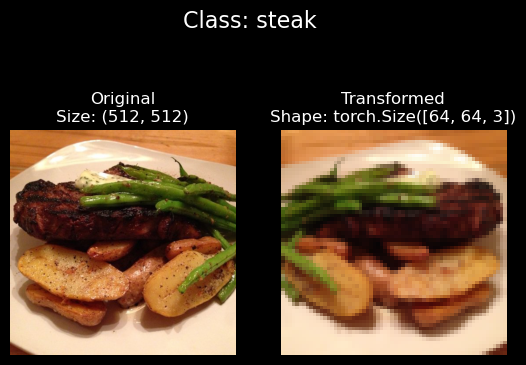

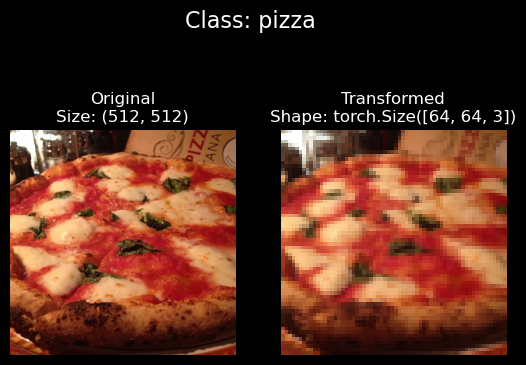

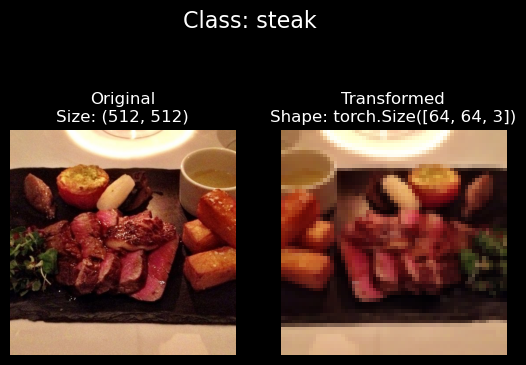

In [215]:
def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # Transform and plot the target image
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3)

## 4. Option1: Loading image data using `ImageFolder`

In [216]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

print(test_data)

Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [217]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [218]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [219]:
# Check the length of our dataset
len(train_data), len(test_data)

(225, 75)

In [220]:
# Index on train_data dataset to get a image and label separately
img, label = train_data[0][0], train_data[0][1]
img

tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0863],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0706],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0196,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0902, 0.0902, 0.

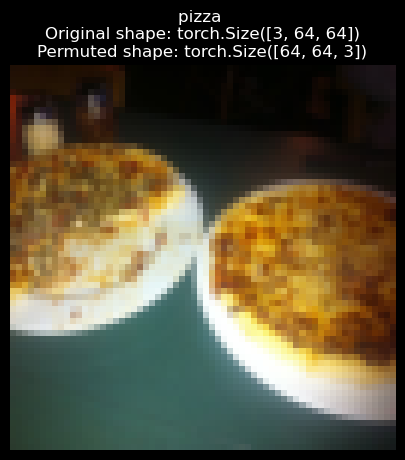

In [221]:
img_permute = img.permute(1, 2, 0)
plt.figure(figsize=(10, 5))
plt.imshow(img_permute)
plt.axis('off')
plt.title(f"{class_names[label]} \nOriginal shape: {img.shape}\nPermuted shape: {img_permute.shape}")
plt.show()

### 4.1 Turn loaded images into `DataLoader`'s

In [222]:
# Turn our data into a DataLoader's
BATCH_SIZE = 32
train_data_loader = DataLoader(dataset=train_data,
                               batch_size=BATCH_SIZE,
                               shuffle=True,
                               num_workers=4)

test_data_loader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=2)

test_data_loader, train_data_loader

(<torch.utils.data.dataloader.DataLoader at 0x1a42c772020>,
 <torch.utils.data.dataloader.DataLoader at 0x1a42c771f00>)

In [223]:
len(train_data_loader), len(train_data)

(8, 225)

In [224]:
img, label = next(iter(train_data_loader))

print(f"Image shape: {img.shape}\nLabel shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])


## 5. Option 2: Loading Image Data with Custom `Dataset`

In [225]:
import os
import pathlib

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [226]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

In [227]:
target_directory = train_dir
target_directory

# Get the class names from the target
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

['pizza', 'steak', 'sushi']

In [228]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in target directory."""
    # 1. Get the class name by scanning the target directory
    classes = list(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. Raise an error if class names could not be found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any class in {directory}... please check file structure.")

    # 3. Put the classes in the dictionary
    class_to_idx = {entry:i for i, entry in enumerate(classes)}

    return classes, class_to_idx

In [229]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

In [230]:
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):
    def __init__(self,
                 targ_dir: str,
                 transform=None):
        # Get all of the image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)

    def load_image(self, index: int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path)
    
    def __len__(self) -> int:
        return len(self.paths)
    
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]
        
        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

In [231]:
# Create a transform
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [232]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transform)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transforms)

In [233]:
train_data_custom.__len__()

225

In [234]:
len(test_data_custom)

75

In [235]:
test_data

Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [236]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [237]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

### 5.2 Create a function to display the random image

In [238]:
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    # Adjust the image to 10 (if n is higher than 10)
    if n > 10:
        n = 10
        display_shape = False
        print("you Can't pick a number more than 10, so we adjust it to 10")
    
    # Set a seed
    if seed:
        random.seed(seed)

    # Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # Setup plot
    plt.figure(figsize=(16, 8))

    # Loop through random indexes and plot them
    for i, target_sample in enumerate(random_samples_idx):
        target_image, target_label = dataset[target_sample][0], dataset[target_sample][1]

        # Change the color channel dimension to be appropriate for matplotlib
        adjusted_target_image = target_image.permute(1, 2, 0)

        # Plot the results
        plt.subplot(1, n, i+1)
        plt.imshow(adjusted_target_image)
        plt.axis('off')
        if classes:
            title = f"Class: {classes[target_label]}"
            if display_shape:
                title = title + f"\nshape: {adjusted_target_image.shape}"
        plt.title(title)

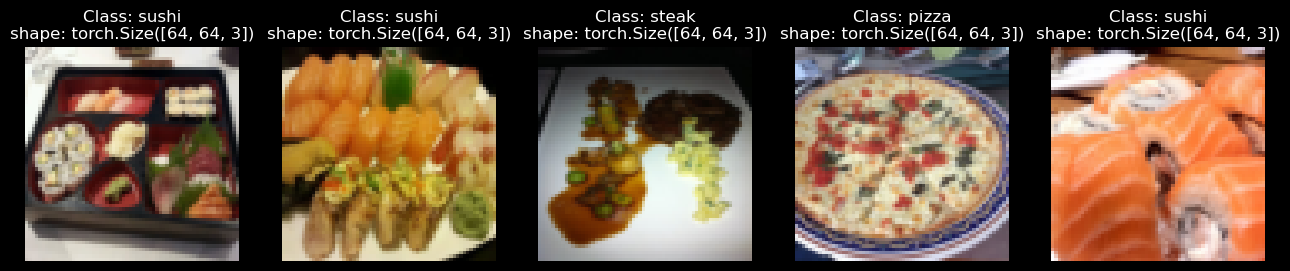

In [239]:
# Display random images with above function (pytorch ImageFolder)
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=None)

you Can't pick a number more than 10, so we adjust it to 10


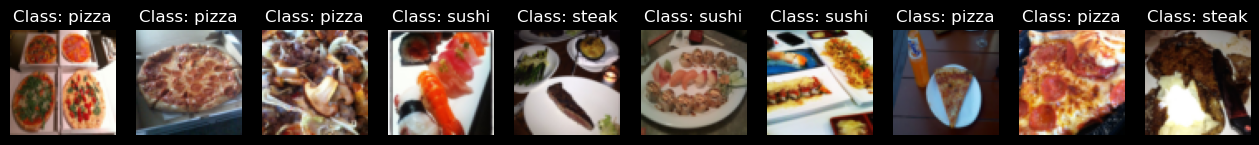

In [240]:
# Display random images from the our custom dataset with our function
display_random_images(train_data_custom,
                      n=50,
                      classes=train_data_custom.classes,
                      seed=None)

### 5.3 Turn data into dataLoaders

In [241]:
BATCH_SIZE = 32
train_data_custom_loader = DataLoader(dataset=train_data_custom,
                                      batch_size=BATCH_SIZE,
                                      shuffle=True,
                                      num_workers=0)

test_data_custom_loader = DataLoader(dataset=test_data_custom,
                                     batch_size=BATCH_SIZE,
                                     shuffle=False,
                                     num_workers=0)

test_data_custom_loader

In [242]:
img_custom, label_custom = next(iter(train_data_custom_loader))
img_custom.shape

torch.Size([32, 3, 64, 64])

## 6. Other forms of transforms (data augmentation)

In [243]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

In [244]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg')]

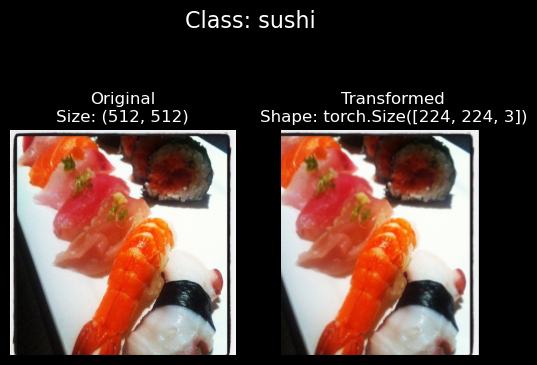

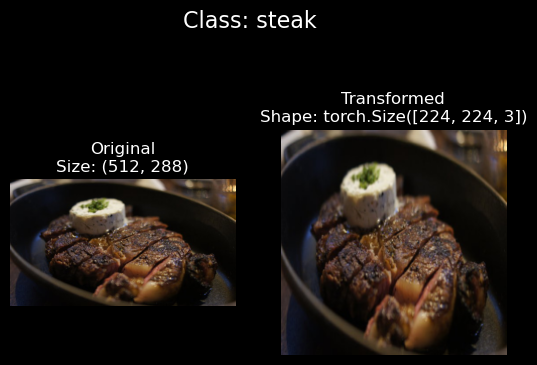

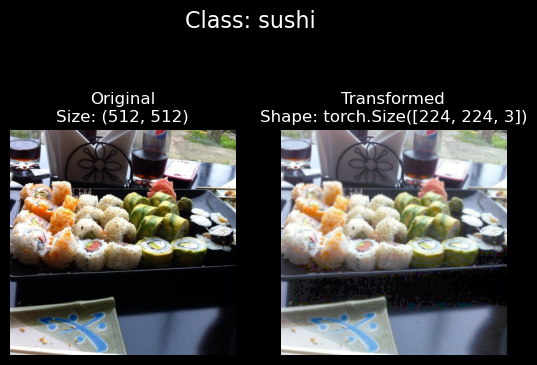

In [245]:
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transform,
    n=3,
    seed=None
)

## 7. Model 0: TinyVGG without data augmentation

### 7.1 Creating transforms and loading data for Model 0

In [246]:
simple_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [247]:
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform)

test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform)

In [248]:
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 6 

train_dataloader_simple= DataLoader(dataset=train_data_simple,
                                      shuffle=True,
                                      num_workers=NUM_WORKERS,
                                      batch_size=BATCH_SIZE)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    shuffle=False,
                                    batch_size=NUM_WORKERS,
                                    num_workers= NUM_WORKERS)

### 7.2 Create tinyVGG model class

In [249]:
class TinyVGG(nn.Module):
    def __init__(self, 
                 input_shape,
                 hidden_layer,
                 output_shape):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_layer,
                      kernel_size=3,
                      padding=0,
                      stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_layer,
                      out_channels=hidden_layer,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_layer,
                      out_channels=hidden_layer,
                      kernel_size=3,
                      padding=0,
                      stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_layer,
                      out_channels=hidden_layer,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_layer*13*13,
                      out_features=output_shape)
        )
    def forward(self, x):
        # x = self.conv_block_1(x)
        # # print(x.shape)
        # x = self.conv_block_2(x)
        # # print(x.shape)
        # x = self.classifier(x)
        # # print(x.shape)
        # return x
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


In [250]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_layer=10,
                  output_shape=len(class_names))

### 7.3 Forward pass for a single input

In [251]:
# image_batch , label_bach = next(iter(train_dataloader_simple))
image_batch = torch.rand([32, 3, 64, 64])

In [252]:
model_0(image_batch)

tensor([[ 0.0219,  0.0011,  0.0110],
        [ 0.0229, -0.0016,  0.0063],
        [ 0.0214, -0.0012,  0.0055],
        [ 0.0206, -0.0008,  0.0082],
        [ 0.0208, -0.0017,  0.0105],
        [ 0.0211, -0.0035,  0.0107],
        [ 0.0210, -0.0014,  0.0082],
        [ 0.0199, -0.0025,  0.0083],
        [ 0.0207, -0.0019,  0.0084],
        [ 0.0218, -0.0022,  0.0097],
        [ 0.0219, -0.0017,  0.0085],
        [ 0.0194, -0.0021,  0.0077],
        [ 0.0227, -0.0031,  0.0096],
        [ 0.0217, -0.0031,  0.0074],
        [ 0.0219, -0.0013,  0.0063],
        [ 0.0220, -0.0007,  0.0076],
        [ 0.0220, -0.0037,  0.0099],
        [ 0.0210, -0.0019,  0.0096],
        [ 0.0216, -0.0009,  0.0082],
        [ 0.0229, -0.0026,  0.0102],
        [ 0.0216,  0.0003,  0.0085],
        [ 0.0217, -0.0015,  0.0061],
        [ 0.0224, -0.0014,  0.0098],
        [ 0.0209, -0.0028,  0.0064],
        [ 0.0186, -0.0043,  0.0073],
        [ 0.0227, -0.0034,  0.0080],
        [ 0.0209, -0.0013,  0.0078],
 

### 7.4 Use `torch info`

In [253]:
# Internet connection Error

### 7.5 Create train and test loops function

In [254]:
def train_step(model, dataLoader, loss_fn, optimizer, device):
    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataLoader):
         X, y = X.to(device), y.to(device)
         y_pred = model(X)
         loss = loss_fn(y_pred, y)
         train_loss += loss.item()

         optimizer.zero_grad()
         loss.backward()
         optimizer.step()

         y_pred_class = y_pred.argmax(dim=1)
         train_acc += ((y_pred_class == y).sum().item()/len(y_pred_class))

         train_loss = train_loss / len(dataLoader)
         train_acc = train_acc / len(dataLoader)
         print(y_pred)
         return train_loss, train_acc

In [255]:
# Create a test step 
def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item() 

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

### 7.6 Create a `train()` function to combine `train_step()` and `test_step()`

In [256]:
def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs:int=5, device=device):
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []}
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,dataLoader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,device=device)
        test_loss, test_acc = test_step(model=model, dataloader=test_dataloader,loss_fn=loss_fn, device=device)
        print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")
        results['train_loss'].append(train_loss)
        results['train_acc'].append(train_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)

    return results

### 7.7 Train and evaluate model 0

In [257]:
# Set random seeds
# torch.manual_seed(42)
# torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 1

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels
                  hidden_layer = 10,
                  output_shape=len(train_data.classes)).to(device)

# Setup Loss function & Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

# Start a timer
from timeit import default_timer as timer
start_time = timer()

# Train_model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        device=device,
                        epochs=NUM_EPOCHS)

# End the timer and print it out
end_time = timer()
print(f"Total training time: {end_time - start_time:.3f} seconds")

tensor([[ 0.0291,  0.0166, -0.0176],
        [ 0.0338,  0.0207, -0.0161],
        [ 0.0266,  0.0182, -0.0188],
        [ 0.0302,  0.0243, -0.0100],
        [ 0.0386,  0.0207, -0.0089],
        [ 0.0320,  0.0160, -0.0140],
        [ 0.0313,  0.0140, -0.0177],
        [ 0.0364,  0.0101, -0.0211],
        [ 0.0303,  0.0236, -0.0067],
        [ 0.0394, -0.0029, -0.0135],
        [ 0.0345,  0.0228, -0.0035],
        [ 0.0323,  0.0212, -0.0173],
        [ 0.0268,  0.0152, -0.0211],
        [ 0.0280,  0.0221, -0.0247],
        [ 0.0408,  0.0100, -0.0223],
        [ 0.0282,  0.0208, -0.0277],
        [ 0.0353,  0.0128, -0.0181],
        [ 0.0420,  0.0263, -0.0160],
        [ 0.0343,  0.0088, -0.0134],
        [ 0.0382,  0.0114, -0.0237],
        [ 0.0422,  0.0098, -0.0308],
        [ 0.0350,  0.0229, -0.0187],
        [ 0.0300,  0.0200, -0.0138],
        [ 0.0286,  0.0190, -0.0101],
        [ 0.0382,  0.0090, -0.0166],
        [ 0.0333,  0.0224, -0.0176],
        [ 0.0333,  0.0158, -0.0265],
 

### 7.8 Plot the loss curves of Model 0

In [258]:
def plot_loss_curves(results):
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15,7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend();

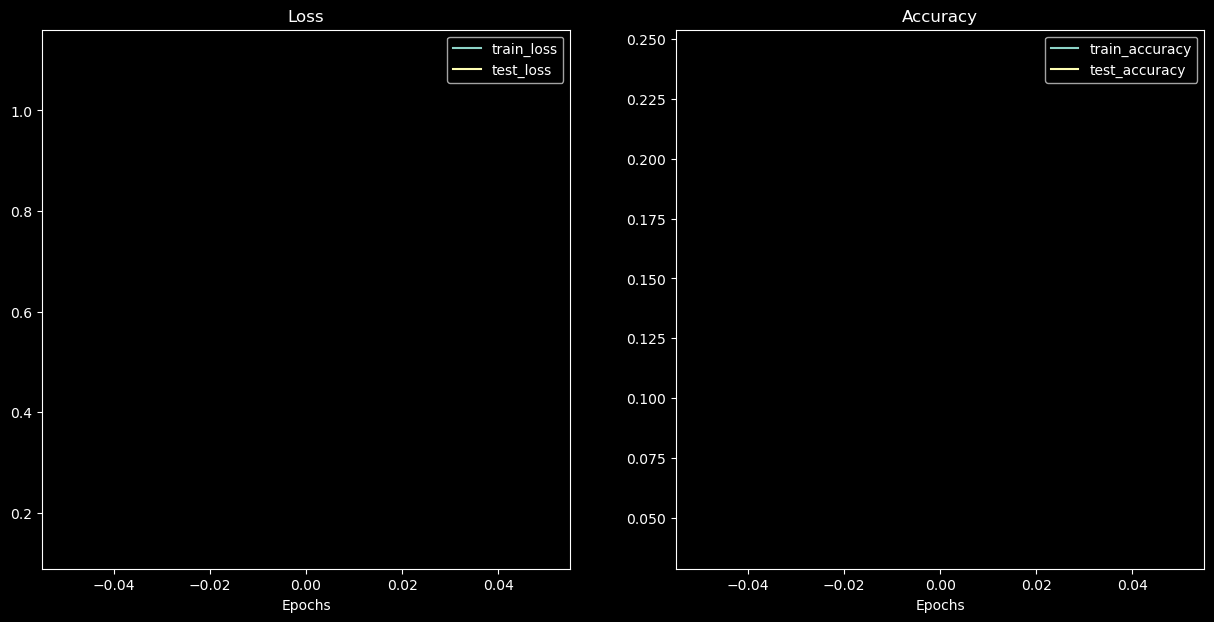

In [259]:
plot_loss_curves(model_0_results)